# Unsupervised Learning — K-Means Clustering
## AI4I 2020 Predictive Maintenance Dataset

**Role:** ML Engineer 2 (Matahari Dhia Alwafy)

## Tujuan

Melakukan clustering kondisi mesin menggunakan K-Means berdasarkan karakteristik operasional mesin.

Feature yang digunakan:
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]

## Tahapan Preprocessing

Tahapan preprocessing yang dilakukan:
1. Data inspection
2. Feature selection
3. Standardisasi menggunakan StandardScaler

In [32]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Library berhasil di-import.")

Library berhasil di-import.


In [33]:
DATA_PATH = "ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

print("Ukuran dataset:", df.shape)
display(df.head())

Ukuran dataset: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [34]:
print("Informasi dataset:")
df.info()

print("\nMissing value:")
display(df.isnull().sum().to_frame("Missing"))

print("\nJumlah duplikasi:", df.duplicated().sum())

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: f

,Missing
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



Jumlah duplikasi: 0


In [35]:
FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[FEATURES].copy()

display(X.head())
display(X.describe().T)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


In [36]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=FEATURES
)

display(X_scaled_df.head())

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588


In [37]:
print("Mean setelah scaling:")
display(X_scaled_df.mean().round(4))

print("\nStd setelah scaling:")
display(X_scaled_df.std().round(4))

Mean setelah scaling:


,0
Air temperature [K],-0.0
Process temperature [K],-0.0
Rotational speed [rpm],-0.0
Torque [Nm],0.0
Tool wear [min],0.0



Std setelah scaling:


,0
Air temperature [K],1.0001
Process temperature [K],1.0001
Rotational speed [rpm],1.0001
Torque [Nm],1.0001
Tool wear [min],1.0001


## Menentukan Jumlah Cluster

Sebelum melakukan training K-Means final, dilakukan analisis untuk menentukan jumlah cluster (K) yang sesuai.

Metode yang digunakan:
- Elbow Method
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score

In [38]:
K_RANGE = range(2, 9)

inertias = []

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    "K": list(K_RANGE),
    "Inertia": inertias
})

display(elbow_df)

,K,Inertia
0,2,36654.191256
1,3,28305.693569
2,4,24870.551403
3,5,21946.716531
4,6,19848.977311
5,7,17896.025114
6,8,16590.967847


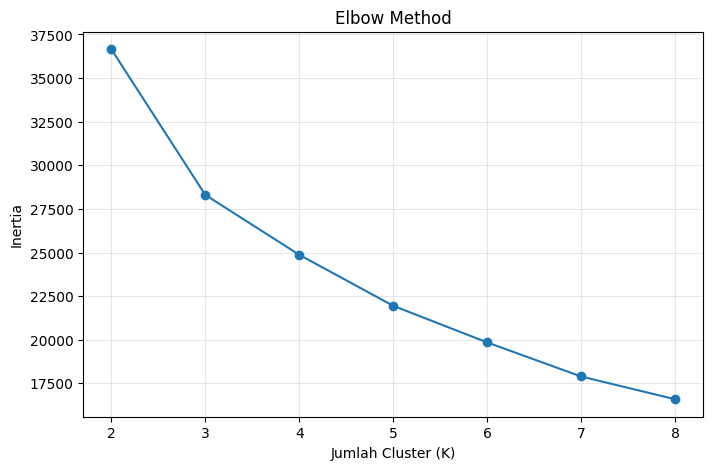

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    elbow_df["K"],
    elbow_df["Inertia"],
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(K_RANGE))
plt.grid(alpha=0.3)

plt.show()

In [40]:
results = []

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    davies_bouldin = davies_bouldin_score(
        X_scaled,
        labels
    )

    calinski = calinski_harabasz_score(
        X_scaled,
        labels
    )

    results.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": davies_bouldin,
        "Calinski-Harabasz Score": calinski
    })

results_df = pd.DataFrame(results)

display(results_df.round(4))

,K,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,2,36654.1913,0.2581,1.5163,3640.2877
1,3,28305.6936,0.2622,1.2437,3830.9968
2,4,24870.5514,0.2376,1.2859,3366.7104
3,5,21946.7165,0.2250,1.3734,3194.0253
4,6,19848.9773,0.2200,1.3332,3036.2428
5,7,17896.0251,0.2256,1.2229,2987.7881
6,8,16590.9678,0.2176,1.2348,2874.4223


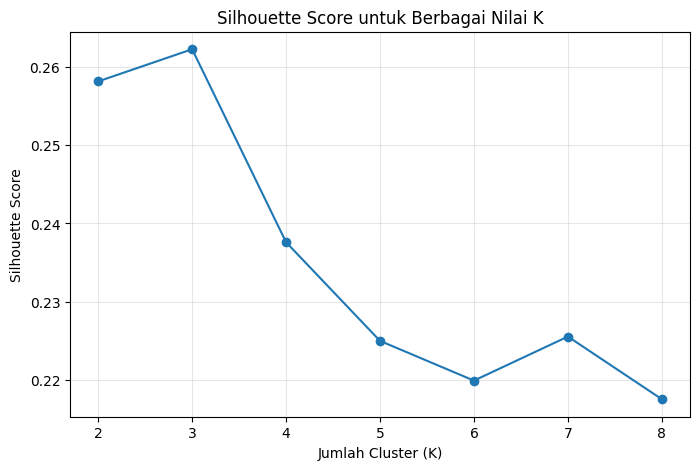

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Berbagai Nilai K")
plt.xticks(list(K_RANGE))
plt.grid(alpha=0.3)

plt.show()

In [42]:
best_k = int(
    results_df.loc[
        results_df["Silhouette Score"].idxmax(),
        "K"
    ]
)

print(
    "K kandidat berdasarkan Silhouette Score:",
    best_k
)

K kandidat berdasarkan Silhouette Score: 3


In [43]:
K_FINAL = best_k

print("K Final Yang Digunakan:", K_FINAL)

K Final Yang Digunakan: 3


## Training K-Means Final

Model K-Means final dilatih menggunakan jumlah cluster (`K_FINAL`) yang telah ditentukan dari hasil analisis sebelumnya.

In [44]:
kmeans_model = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["Cluster"] = cluster_labels

print("Training K-Means selesai.")

Training K-Means selesai.


In [45]:
cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_distribution = pd.DataFrame({
    "Jumlah Data": cluster_counts,
    "Persentase": (
        cluster_counts / len(df_clustered) * 100
    ).round(2)
})

display(cluster_distribution)

,Jumlah Data,Persentase
Cluster,,
0,3930,39.30
1,4017,40.17
2,2053,20.53


Evaluasi Model K-Means Final

In [46]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

final_davies_bouldin = davies_bouldin_score(
    X_scaled,
    cluster_labels
)

final_calinski = calinski_harabasz_score(
    X_scaled,
    cluster_labels
)

metrics_df = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ],
    "Value": [
        final_silhouette,
        final_davies_bouldin,
        final_calinski
    ]
})

display(metrics_df.round(4))

,Metric,Value
0,Silhouette Score,0.2622
1,Davies-Bouldin Index,1.2437
2,Calinski-Harabasz Score,3830.9968


### Interpretasi Metrik

- **Silhouette Score:** semakin tinggi menunjukkan pemisahan cluster yang semakin baik.
- **Davies-Bouldin Index:** semakin rendah menunjukkan cluster yang semakin terpisah.
- **Calinski-Harabasz Score:** semakin tinggi menunjukkan struktur cluster yang lebih baik.

In [47]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

display(pca_df.head())

,PC1,PC2,Cluster
0,-1.093847,-0.854210,1
1,-1.602678,-0.215765,1
2,-1.599406,-0.401641,1
3,-1.230438,-0.664604,1
4,-1.289814,-0.535153,1


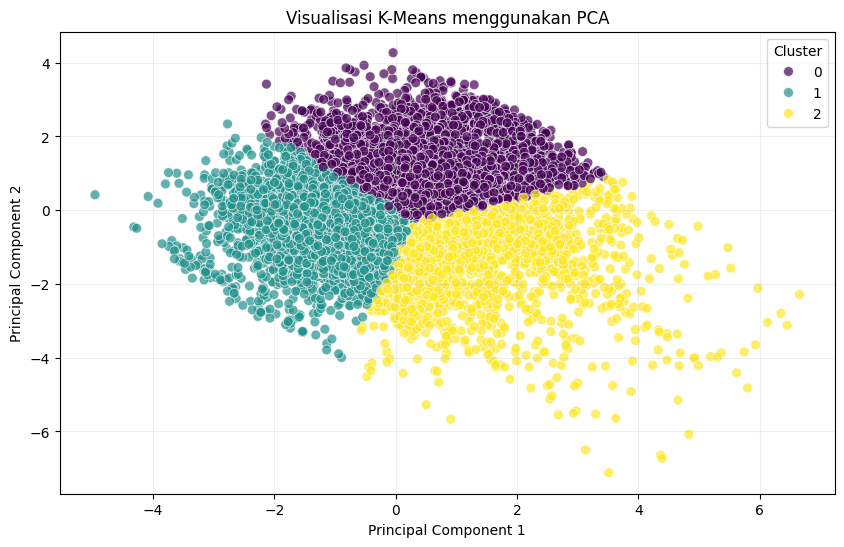

In [48]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=50,
    alpha=0.7
)

plt.title("Visualisasi K-Means menggunakan PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.2)

plt.show()

In [49]:
cluster_profile = (
    df_clustered
    .groupby("Cluster")[FEATURES]
    .mean()
    .round(2)
)

display(cluster_profile)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Cluster,,,,,
0,301.72,311.25,1469.81,43.64,110.36
1,298.26,308.74,1474.14,43.26,104.62
2,300.12,310.10,1797.26,26.57,109.85


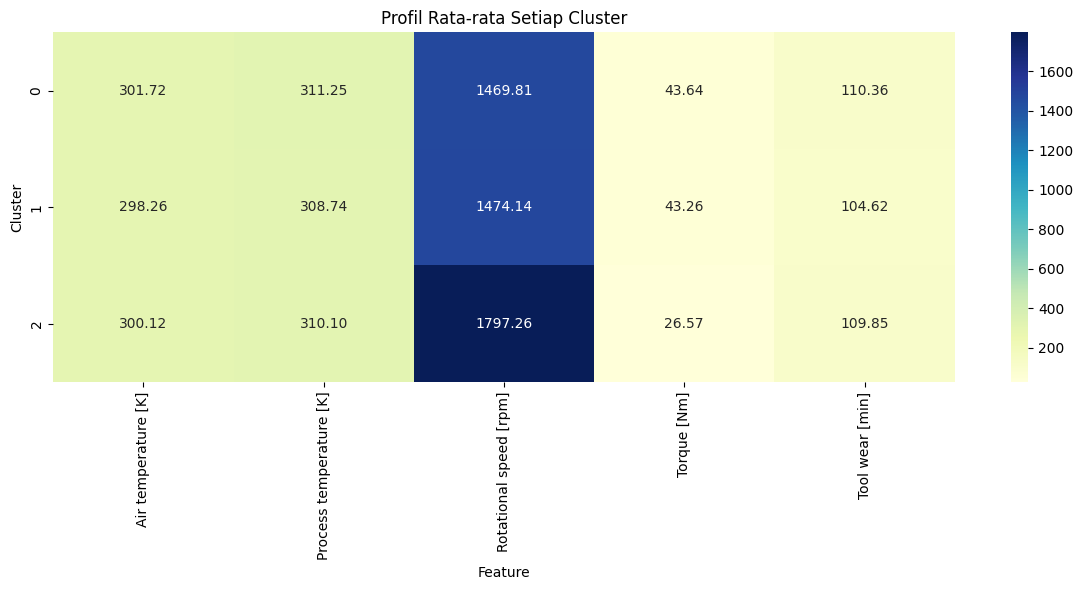

In [50]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Profil Rata-rata Setiap Cluster")
plt.xlabel("Feature")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()